# Task 3 -- Verification of the Edgewise BEMT Model (Sec 3)

**3.1** mu -> 0 recovery: edgewise engine at V_edge=0 vs. the already-validated Milestone-1 axial `BEMTSolver`, across a collective sweep. By construction (see `edgewise_bemt.py`) these should agree to numerical tolerance -- the cheapest, highest-value correctness check for the whole milestone.

**3.2** Azimuthal loading contour: a full (r, psi) heatmap at a representative forward-flight point -- peak loading on the advancing side, a reverse-flow patch near the retreating-side root.

**3.3** Discretization sensitivity: CT convergence vs. n_stations and n_azimuth, to justify the station counts used everywhere else.

In [1]:
import os
import csv
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from bemt_solver import FlightCondition, BEMTSolver, error_metrics
from task5_tiltrotor_design import TILTROTOR_GEOM, TILTROTOR_AIRFOIL, RPM_HOVER
from edgewise_bemt import EdgewiseFlightCondition, EdgewiseBEMTSolver

FIG_DIR = "figures"
OUT_DIR = "outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

axial_solver = BEMTSolver(TILTROTOR_GEOM, TILTROTOR_AIRFOIL)
edge_solver = EdgewiseBEMTSolver(TILTROTOR_GEOM, TILTROTOR_AIRFOIL)

# Collective range kept at/above 12 deg: below that the underlying M1 axial
# bisection solve fails to bracket a root for this rotor/airfoil combination
# (flagged separately in dev_notes_bemt_quirks.md) -- not a Milestone-2 bug,
# but verification has to be run where the baseline itself is trustworthy.
COLLECTIVE_SWEEP_DEG = np.arange(12.0, 22.0 + 1e-6, 1.0)

## 3.1 -- mu -> 0 recovery

In [2]:
axial_T, axial_Q, axial_CT, axial_CQ = [], [], [], []
edge_T, edge_Q, edge_CT, edge_CQ = [], [], [], []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # bisection edge-case warnings, not this check's concern
    for th0 in COLLECTIVE_SWEEP_DEG:
        axf = FlightCondition.from_rpm(RPM_HOVER, th0)
        ax_res = axial_solver.solve(axf)
        axial_T.append(ax_res["T"]); axial_Q.append(ax_res["Q"])
        axial_CT.append(ax_res["CT"]); axial_CQ.append(ax_res["CQ"])

        edf = EdgewiseFlightCondition.from_rpm(RPM_HOVER, th0, V_edge=0.0)
        ed_res = edge_solver.solve(edf)
        edge_T.append(ed_res["T"]); edge_Q.append(ed_res["Q"])
        edge_CT.append(ed_res["CT"]); edge_CQ.append(ed_res["CQ"])

axial_T, edge_T = np.array(axial_T), np.array(edge_T)
axial_Q, edge_Q = np.array(axial_Q), np.array(edge_Q)
axial_CT, edge_CT = np.array(axial_CT), np.array(edge_CT)
axial_CQ, edge_CQ = np.array(axial_CQ), np.array(edge_CQ)

T_metrics = error_metrics(edge_T, axial_T)
Q_metrics = error_metrics(edge_Q, axial_Q)
max_abs_CT_diff = float(np.max(np.abs(edge_CT - axial_CT)))
max_abs_CQ_diff = float(np.max(np.abs(edge_CQ - axial_CQ)))

print(f"T:  RMSE={T_metrics['RMSE']:.3e} N   MAE={T_metrics['MAE']:.3e} N   "
      f"MAPE={T_metrics['MAPE_percent']:.4f}%")
print(f"Q:  RMSE={Q_metrics['RMSE']:.3e} N.m MAE={Q_metrics['MAE']:.3e} N.m "
      f"MAPE={Q_metrics['MAPE_percent']:.4f}%")
print(f"max|CT_edge - CT_axial| = {max_abs_CT_diff:.3e}")
print(f"max|CQ_edge - CQ_axial| = {max_abs_CQ_diff:.3e}")
passed = max_abs_CT_diff < 1e-8 and max_abs_CQ_diff < 1e-8
print(f"-> recovery check {'PASSED' if passed else 'FAILED'} (tolerance 1e-8 on CT/CQ)")

with open(os.path.join(OUT_DIR, "task3_1_mu_zero_recovery.csv"), "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["theta0_deg", "T_axial", "T_edgewise", "Q_axial", "Q_edgewise",
                      "CT_axial", "CT_edgewise", "CQ_axial", "CQ_edgewise"])
    for i, th0 in enumerate(COLLECTIVE_SWEEP_DEG):
        writer.writerow([th0, axial_T[i], edge_T[i], axial_Q[i], edge_Q[i],
                          axial_CT[i], edge_CT[i], axial_CQ[i], edge_CQ[i]])

T:  RMSE=3.878e-13 N   MAE=1.654e-13 N   MAPE=0.0000%
Q:  RMSE=9.695e-14 N.m MAE=4.134e-14 N.m MAPE=0.0000%
max|CT_edge - CT_axial| = 8.674e-19
max|CQ_edge - CQ_axial| = 1.084e-19
-> recovery check PASSED (tolerance 1e-8 on CT/CQ)


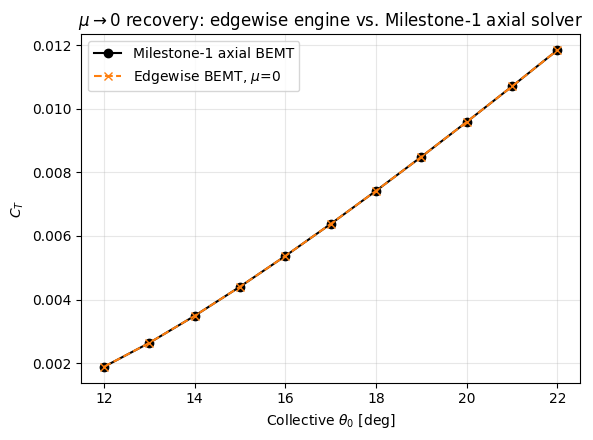

In [3]:
plt.figure(figsize=(6, 4.5))
plt.plot(COLLECTIVE_SWEEP_DEG, axial_CT, "o-", color="black", label="Milestone-1 axial BEMT")
plt.plot(COLLECTIVE_SWEEP_DEG, edge_CT, "x--", color="tab:orange",
          label=r"Edgewise BEMT, $\mu$=0")
plt.xlabel(r"Collective $\theta_0$ [deg]")
plt.ylabel(r"$C_T$")
plt.title(r"$\mu \to 0$ recovery: edgewise engine vs. Milestone-1 axial solver")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task3_1_mu_zero_recovery.png"), dpi=160)
plt.show()

## 3.2 -- azimuthal loading contour

mu=0.1714, reverse-flow fraction=0.57%, advancing-tip Mach=0.703


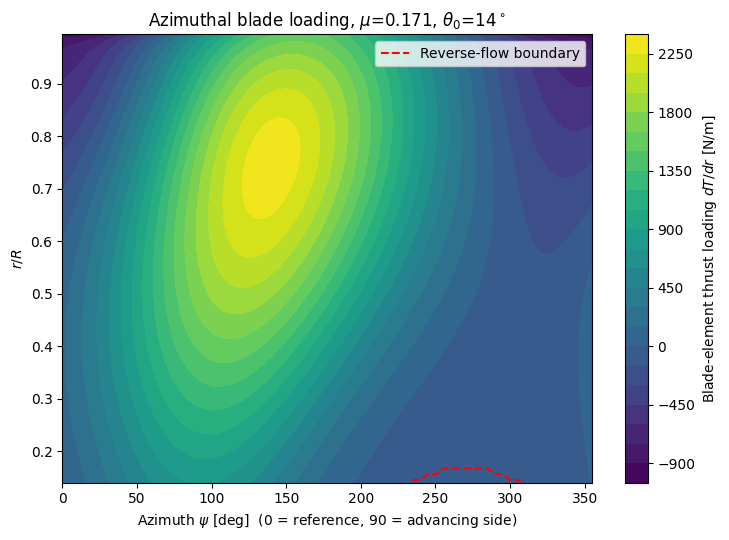

In [4]:
theta0_deg, V_edge, V_axial = 14.0, 35.0, 0.0
flight = EdgewiseFlightCondition.from_rpm(RPM_HOVER, theta0_deg, V_axial=V_axial, V_edge=V_edge)
res = edge_solver.solve(flight)
print(f"mu={res['mu']:.4f}, reverse-flow fraction={res['reverse_flow_fraction']*100:.2f}%, "
      f"advancing-tip Mach={res['M_adv_tip']:.3f}")

psi_deg = np.degrees(res["psi"])
r_over_R = res["r_over_R"]
PSI, RR = np.meshgrid(psi_deg, r_over_R)

plt.figure(figsize=(7.5, 5.5))
cf = plt.contourf(PSI, RR, res["dT_blade"], levels=25, cmap="viridis")
plt.colorbar(cf, label="Blade-element thrust loading $dT/dr$ [N/m]")
if np.any(res["reverse_flow"]):
    plt.contour(PSI, RR, res["reverse_flow"].astype(float), levels=[0.5],
                colors="red", linewidths=1.5, linestyles="--")
    plt.plot([], [], color="red", linestyle="--", label="Reverse-flow boundary")
    plt.legend(loc="upper right")
plt.xlabel(r"Azimuth $\psi$ [deg]  (0 = reference, 90 = advancing side)")
plt.ylabel(r"$r/R$")
plt.title(f"Azimuthal blade loading, $\\mu$={res['mu']:.3f}, "
          f"$\\theta_0$={theta0_deg:.0f}$^\\circ$")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task3_2_azimuthal_contour.png"), dpi=160)
plt.show()

## 3.3 -- discretization sensitivity

In [5]:
theta0_deg, V_edge = 14.0, 35.0
n_stations_list = [20, 40, 60, 80, 120, 160]
n_azimuth_list = [12, 18, 24, 36, 48, 72, 96]

CT_vs_nr = []
for n_r in n_stations_list:
    geom_n = TILTROTOR_GEOM.__class__(**{**TILTROTOR_GEOM.__dict__, "n_stations": n_r})
    solver_n = EdgewiseBEMTSolver(geom_n, TILTROTOR_AIRFOIL)
    flight = EdgewiseFlightCondition.from_rpm(RPM_HOVER, theta0_deg, V_edge=V_edge)
    res_n = solver_n.solve(flight)
    CT_vs_nr.append(res_n["CT"])
CT_vs_nr = np.array(CT_vs_nr)
print("CT vs n_stations:", dict(zip(n_stations_list, np.round(CT_vs_nr, 6))))

CT_vs_npsi = []
for n_psi in n_azimuth_list:
    flight = EdgewiseFlightCondition.from_rpm(RPM_HOVER, theta0_deg, V_edge=V_edge, n_azimuth=n_psi)
    res_n = edge_solver.solve(flight)
    CT_vs_npsi.append(res_n["CT"])
CT_vs_npsi = np.array(CT_vs_npsi)
print("CT vs n_azimuth:", dict(zip(n_azimuth_list, np.round(CT_vs_npsi, 6))))

with open(os.path.join(OUT_DIR, "task3_3_discretization_sensitivity.csv"), "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["n_stations", "CT_vs_n_stations", "n_azimuth", "CT_vs_n_azimuth"])
    n_rows = max(len(n_stations_list), len(n_azimuth_list))
    for i in range(n_rows):
        row = [
            n_stations_list[i] if i < len(n_stations_list) else "",
            CT_vs_nr[i] if i < len(n_stations_list) else "",
            n_azimuth_list[i] if i < len(n_azimuth_list) else "",
            CT_vs_npsi[i] if i < len(n_azimuth_list) else "",
        ]
        writer.writerow(row)

CT vs n_stations: {20: np.float64(0.004079), 40: np.float64(0.004073), 60: np.float64(0.004071), 80: np.float64(0.00407), 120: np.float64(0.00407), 160: np.float64(0.004069)}
CT vs n_azimuth: {12: np.float64(0.00407), 18: np.float64(0.00407), 24: np.float64(0.00407), 36: np.float64(0.00407), 48: np.float64(0.00407), 72: np.float64(0.00407), 96: np.float64(0.00407)}


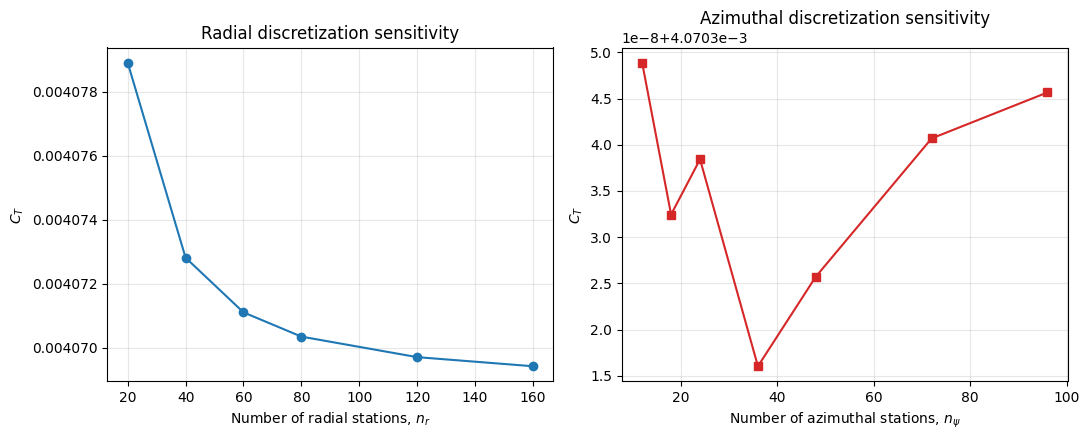

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(n_stations_list, CT_vs_nr, "o-", color="tab:blue")
axes[0].set_xlabel("Number of radial stations, $n_r$")
axes[0].set_ylabel("$C_T$")
axes[0].set_title("Radial discretization sensitivity")
axes[0].grid(alpha=0.3)

axes[1].plot(n_azimuth_list, CT_vs_npsi, "s-", color="tab:red")
axes[1].set_xlabel(r"Number of azimuthal stations, $n_\psi$")
axes[1].set_ylabel("$C_T$")
axes[1].set_title("Azimuthal discretization sensitivity")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task3_3_discretization_sensitivity.png"), dpi=160)
plt.show()

## Summary

In [7]:
print(f"mu->0 recovery: {'PASSED' if passed else 'FAILED -- investigate before proceeding'}")

mu->0 recovery: PASSED
